In [6]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(8,6))
sns.set_style("whitegrid")

<Figure size 800x600 with 0 Axes>

In [11]:
# =========================
# LOAD DATA
# =========================

df=pd.read_csv("processed_online_shoppers.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Month_encoded,VisitorType_encoded,TotalTime
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,1,1,1,Returning_Visitor,0,0,2.0,2,0.000000
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,2,2,1,2,Returning_Visitor,0,0,2.0,2,64.000000
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,4,1,9,3,Returning_Visitor,0,0,2.0,2,0.000000
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,3,2,2,4,Returning_Visitor,0,0,2.0,2,2.666667
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,3,3,1,4,Returning_Visitor,1,0,2.0,2,627.500000


In [8]:
df.shape

(12205, 21)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  str    
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12205 no

In [13]:
missing_percent=(
df.isnull().sum()
/
len(df)
*100
)

missing_percent.sort_values(
ascending=False
)

Month_encoded              2.335109
Administrative_Duration    0.000000
Informational              0.000000
Informational_Duration     0.000000
Administrative             0.000000
ProductRelated             0.000000
ProductRelated_Duration    0.000000
ExitRates                  0.000000
BounceRates                0.000000
SpecialDay                 0.000000
Month                      0.000000
OperatingSystems           0.000000
PageValues                 0.000000
Browser                    0.000000
Region                     0.000000
VisitorType                0.000000
TrafficType                0.000000
Weekend                    0.000000
Revenue                    0.000000
VisitorType_encoded        0.000000
TotalTime                  0.000000
dtype: float64

In [10]:
# =========================
# PHÂN LOẠI BIẾN
# =========================

continuous_cols = [

    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'TotalTime'

]

categorical_cols = [

    'Month',
    'VisitorType',
    'Weekend',
    'Revenue',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'

]

print("Continuous variables:")
print(continuous_cols)

print("\nCategorical variables:")
print(categorical_cols)

Continuous variables:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'TotalTime']

Categorical variables:
['Month', 'VisitorType', 'Weekend', 'Revenue', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,9.000000,94.700000,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.014231,0.025000,0.048529,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,1.000000


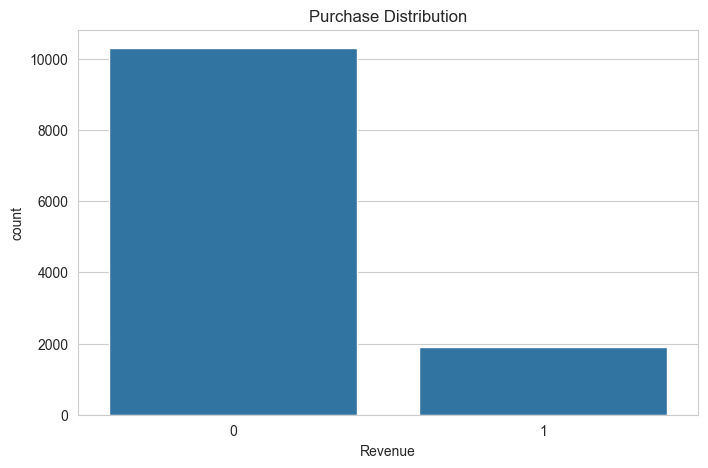

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
x='Revenue',
data=df
)

plt.title(
'Purchase Distribution'
)

plt.show()

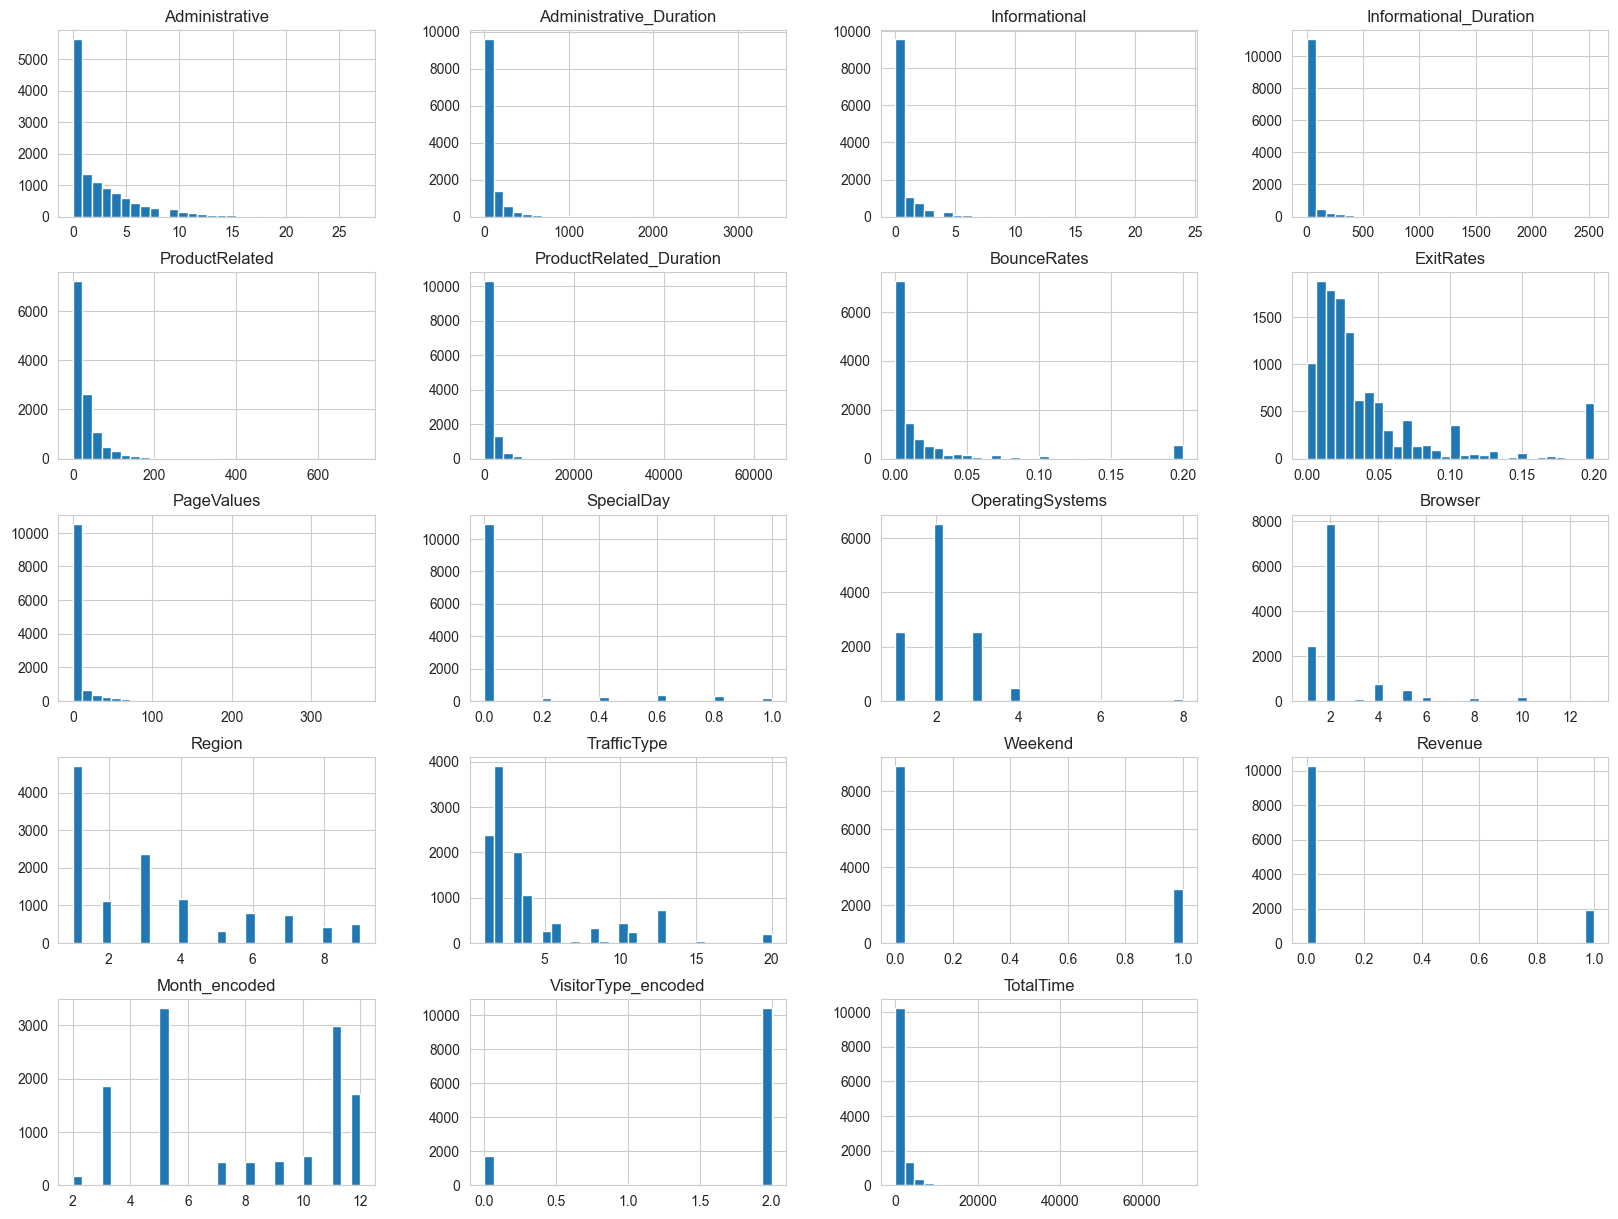

In [15]:
df.hist(
figsize=(20,15),
bins=30
)

plt.show()

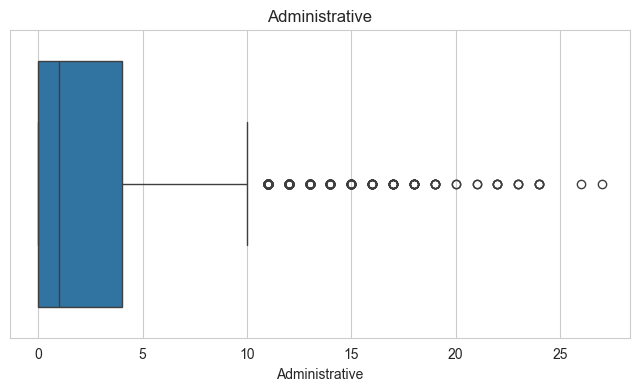

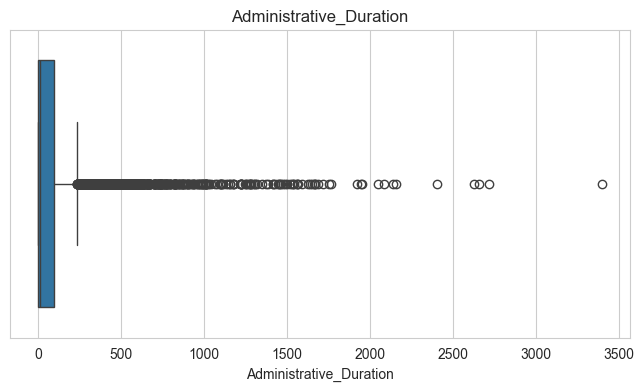

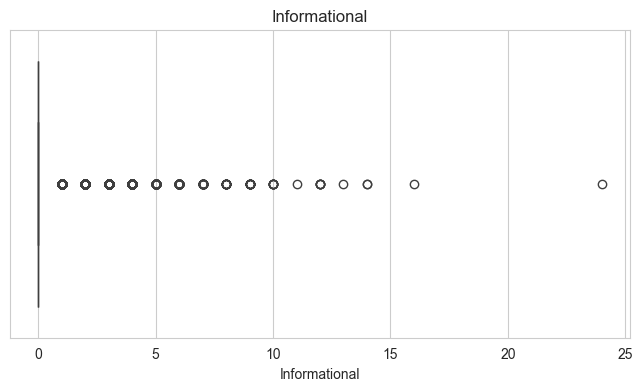

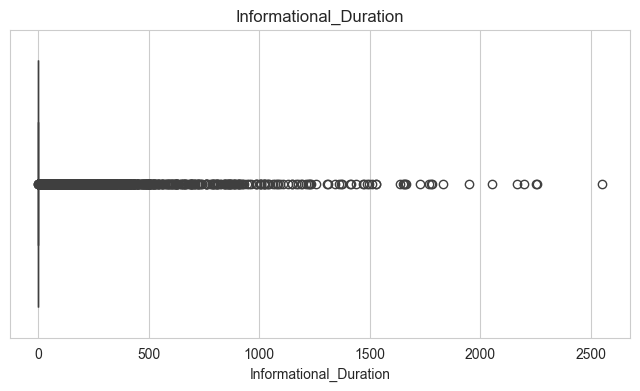

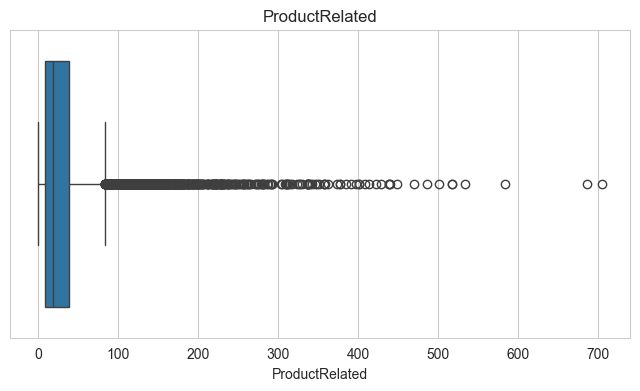

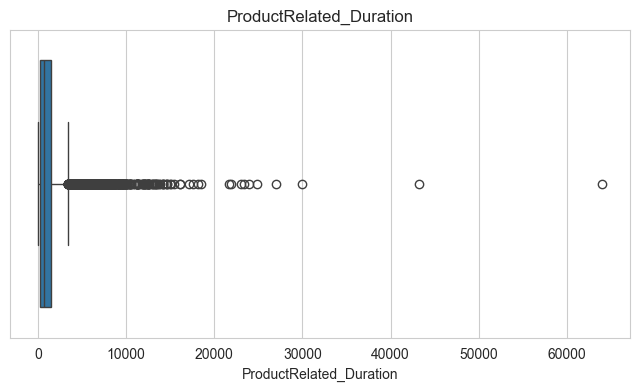

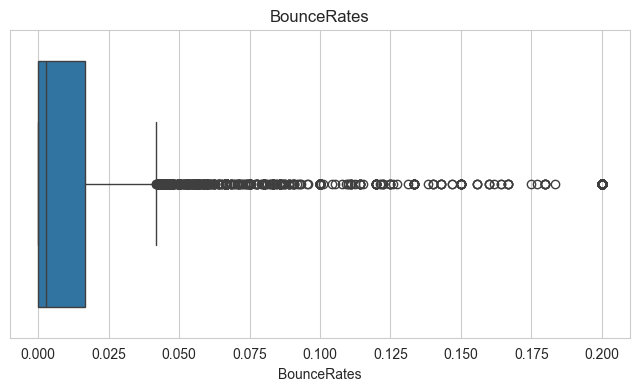

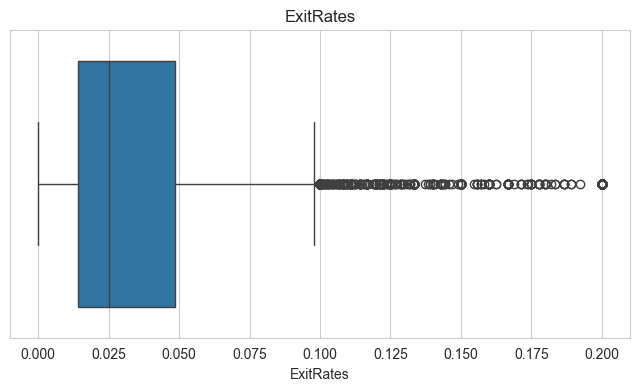

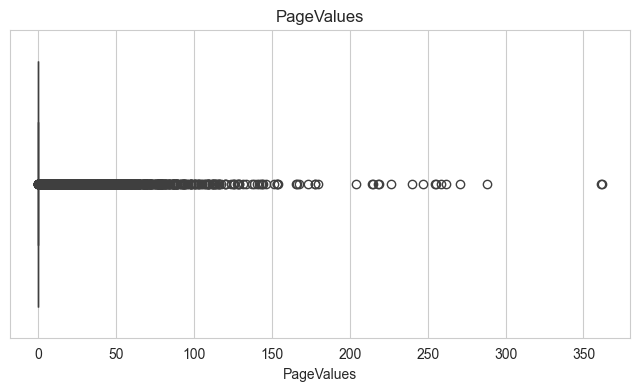

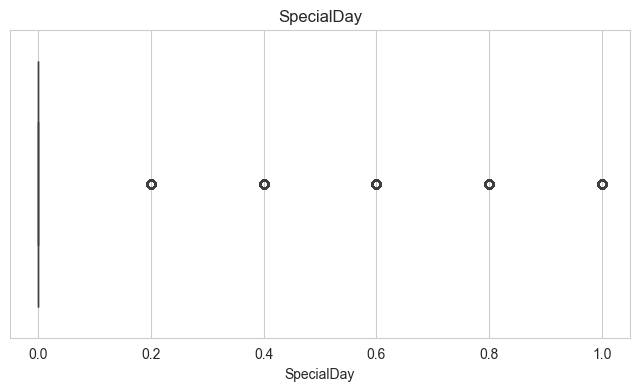

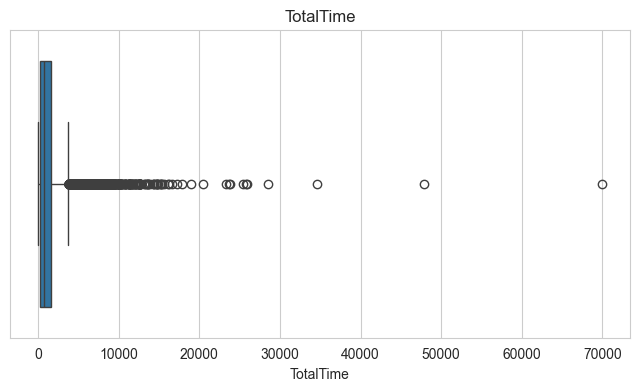

In [16]:
for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
    x=df[col]
    )

    plt.title(col)

    plt.show()

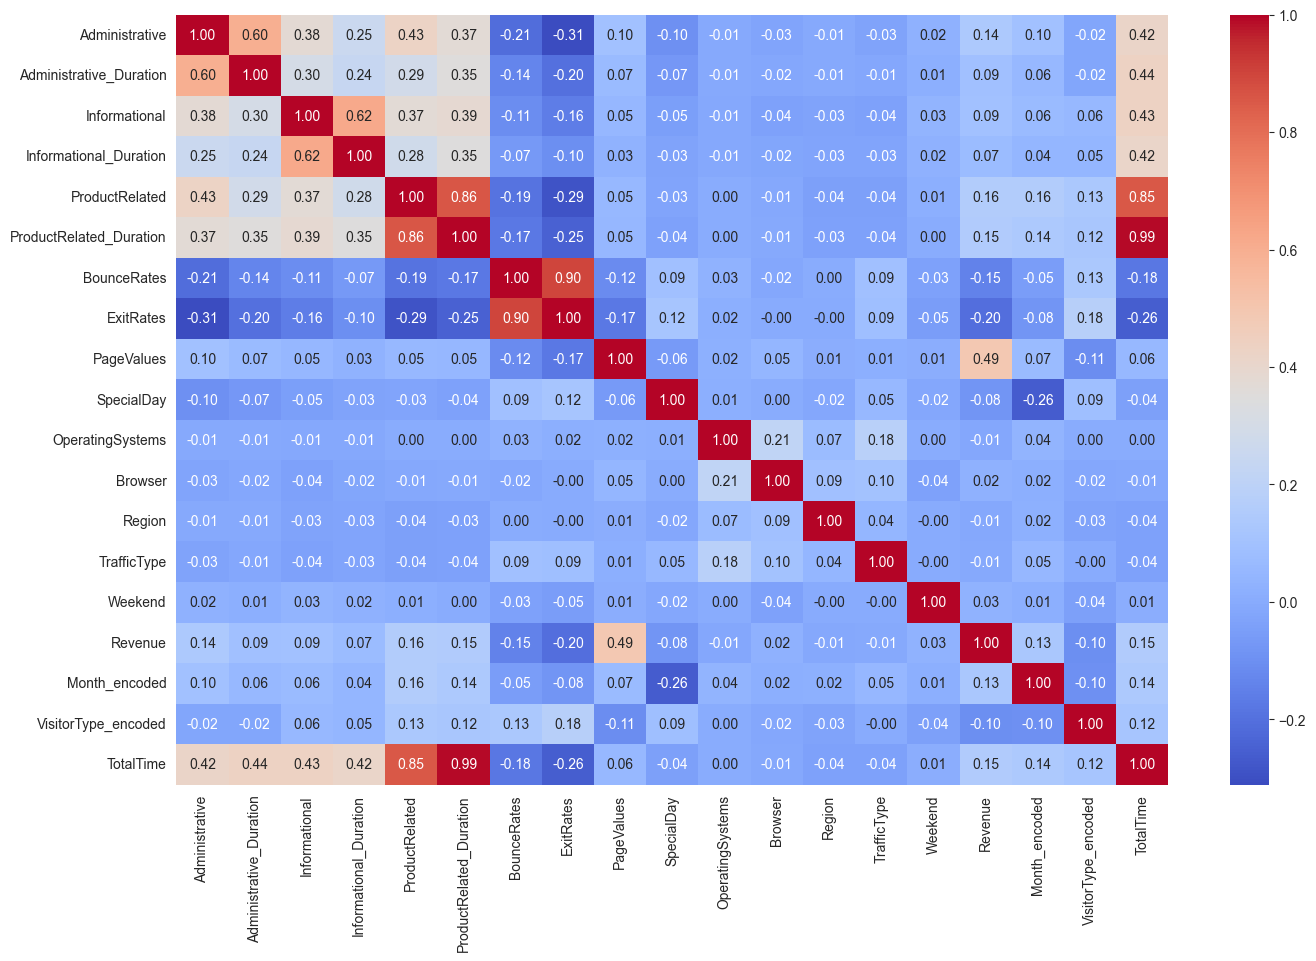

In [17]:
plt.figure(
figsize=(16,10)
)

corr=df.corr(
numeric_only=True
)

sns.heatmap(

corr,

annot=True,
fmt='.2f',
cmap='coolwarm'
)

plt.show()

In [18]:
corr_target=(
corr["Revenue"]
.sort_values(
ascending=False
)
)

corr_target

Revenue                    1.000000
PageValues                 0.491894
ProductRelated             0.156042
TotalTime                  0.153720
ProductRelated_Duration    0.150077
Administrative             0.136330
Month_encoded              0.126064
Informational              0.093626
Administrative_Duration    0.091768
Informational_Duration     0.069358
Weekend                    0.027729
Browser                    0.024052
TrafficType               -0.005618
Region                    -0.012725
OperatingSystems          -0.014927
SpecialDay                -0.083601
VisitorType_encoded       -0.103469
BounceRates               -0.145091
ExitRates                 -0.204320
Name: Revenue, dtype: float64

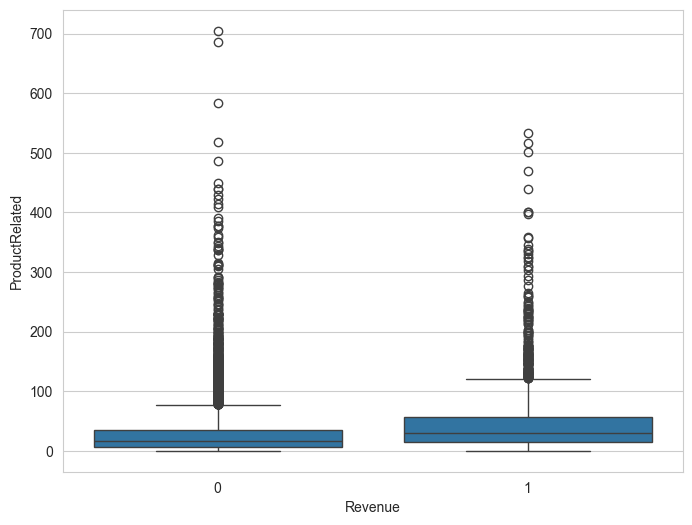

In [19]:
plt.figure(
figsize=(8,6)
)

sns.boxplot(

x='Revenue',

y='ProductRelated',

data=df

)

plt.show()

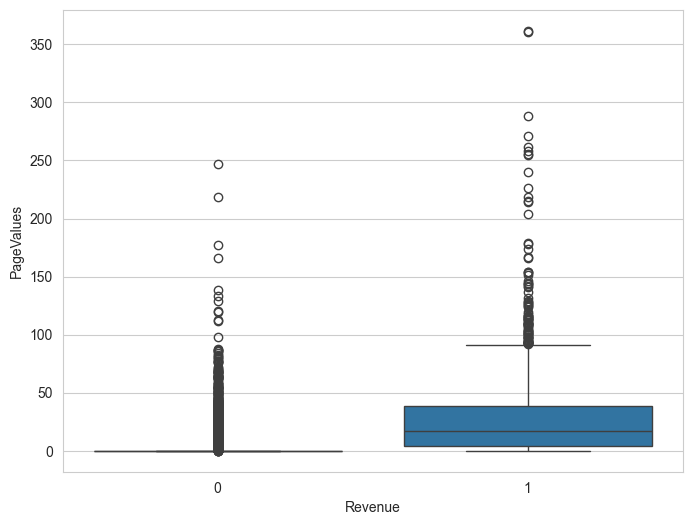

In [20]:
plt.figure(
figsize=(8,6)
)

sns.boxplot(

x='Revenue',

y='PageValues',

data=df

)

plt.show()

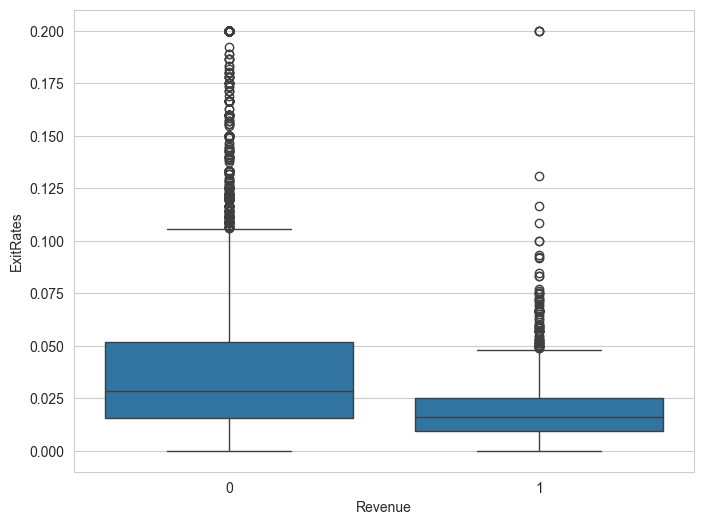

In [21]:
plt.figure(
figsize=(8,6)
)

sns.boxplot(

x='Revenue',

y='ExitRates',

data=df

)

plt.show()

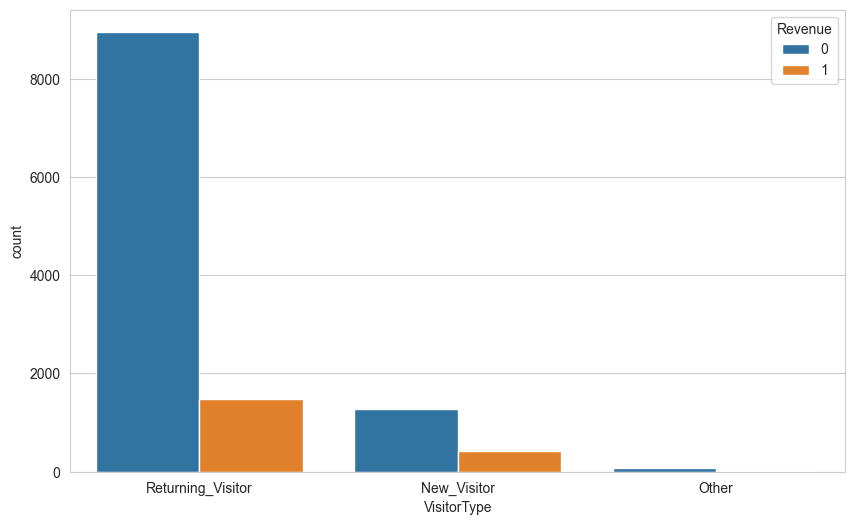

In [22]:
plt.figure(
figsize=(10,6)
)

sns.countplot(

x='VisitorType',

hue='Revenue',

data=df

)

plt.show()

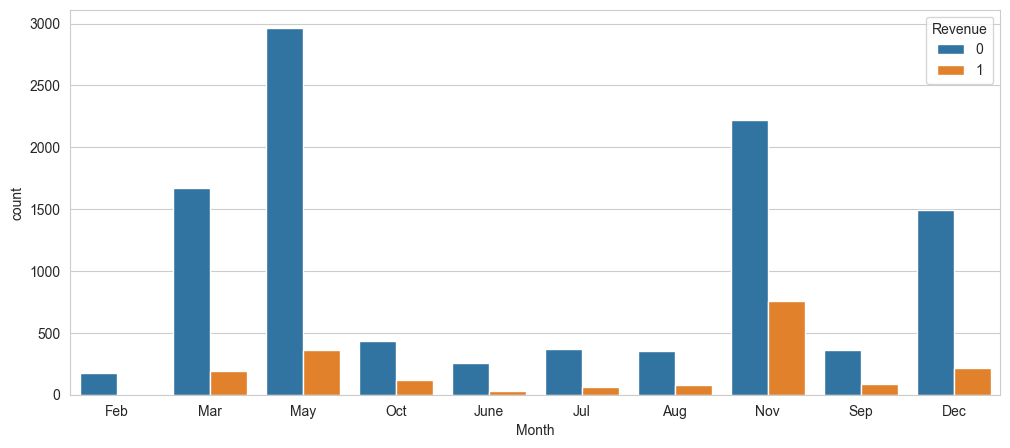

In [23]:
plt.figure(
figsize=(12,5)
)

sns.countplot(

x='Month',

hue='Revenue',

data=df

)

plt.show()

In [25]:
# =========================
# PURCHASE RATE BY MONTH
# =========================

conversion = pd.crosstab(

    df['Month'],
    df['Revenue'],

    normalize='index'

)*100


conversion

Revenue,0,1
Month,,
Aug,82.448037,17.551963
Dec,87.338804,12.661196
Feb,98.342541,1.657459
Jul,84.722222,15.277778
June,89.824561,10.175439
Mar,89.677419,10.322581
May,89.035746,10.964254
Nov,74.513749,25.486251
Oct,79.052823,20.947177


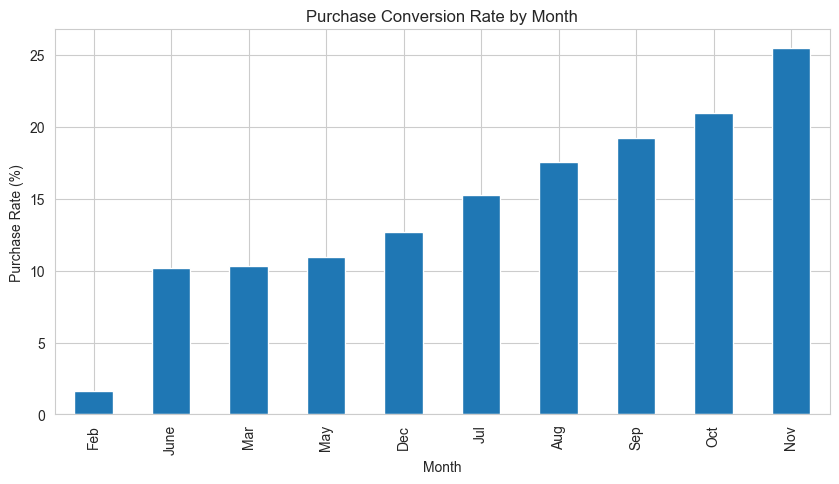

In [26]:
plt.figure(figsize=(10,5))

conversion[1].sort_values().plot(
    kind='bar'
)

plt.ylabel("Purchase Rate (%)")

plt.title(
    "Purchase Conversion Rate by Month"
)

plt.show()

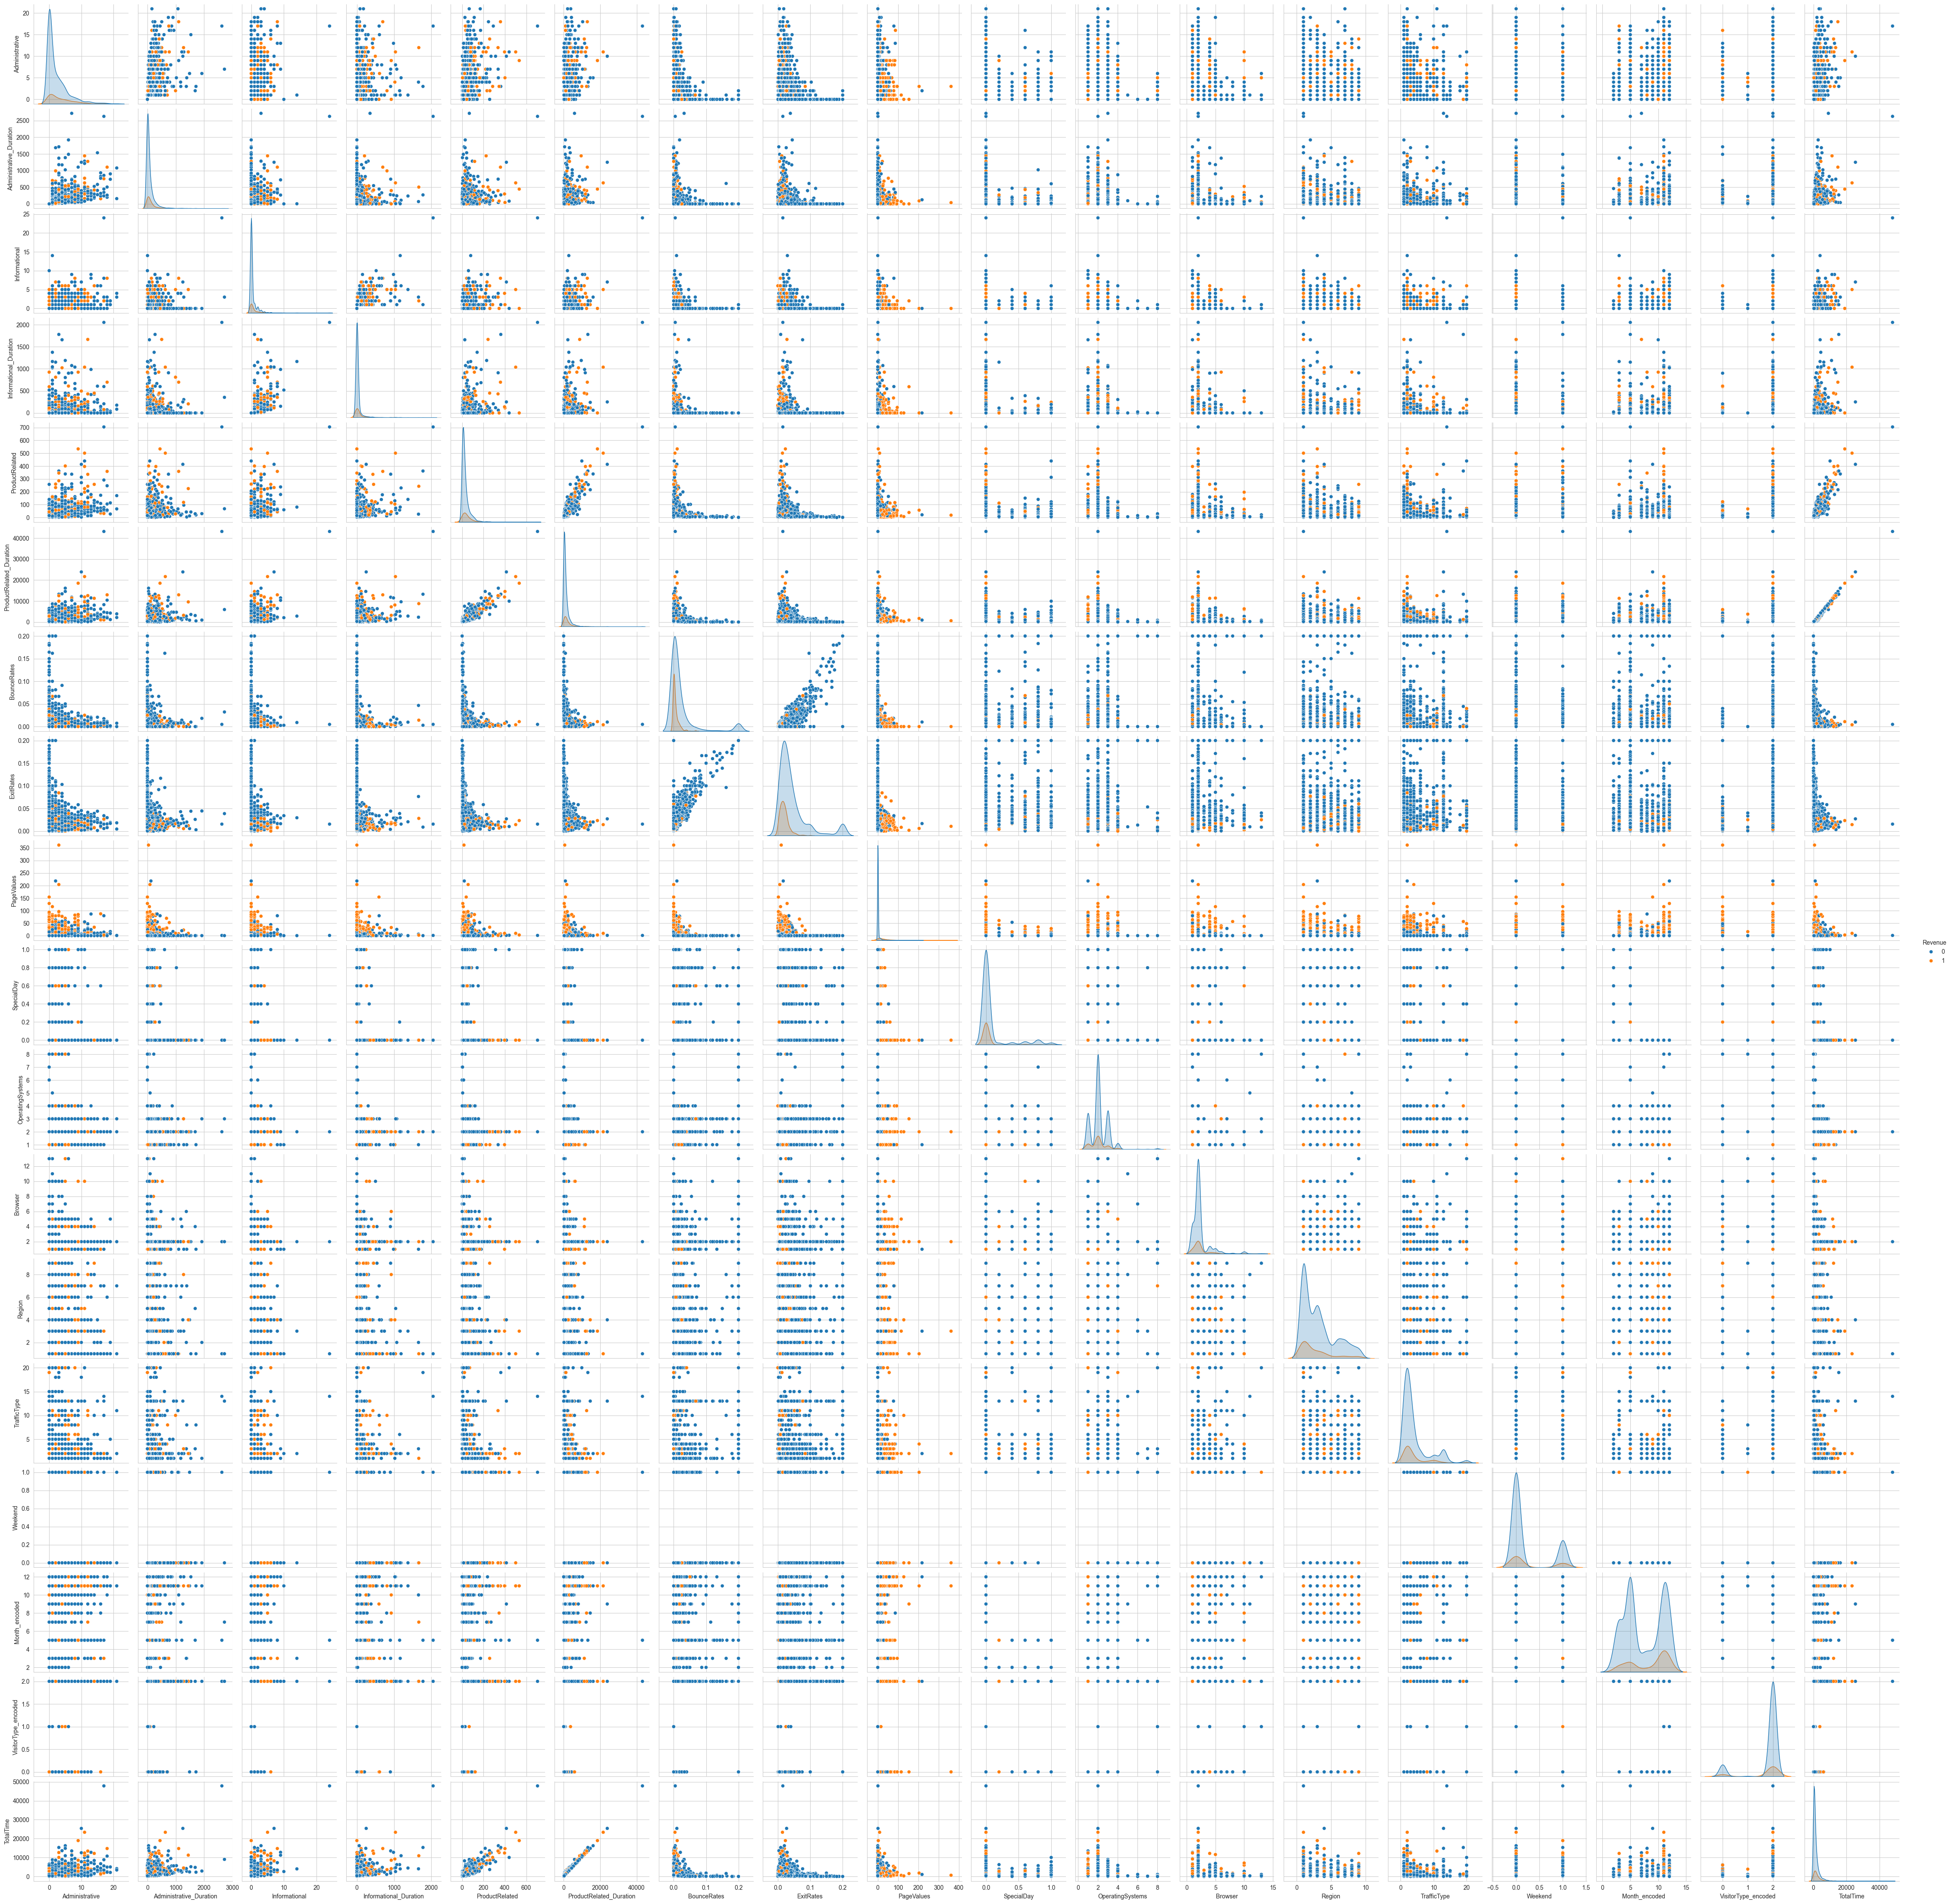

In [24]:
sample=df.sample(
2000
)

sns.pairplot(

sample,

hue='Revenue'

)

plt.show()